In [41]:
import networkx as nx
import matplotlib.pyplot as plt

In [42]:
#All from other notebook
#initialization
import matplotlib.pyplot as plt
import numpy as np
import math

# importing Qiskit
from qiskit_aer import Aer
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile

# import basic plot tools
from qiskit.visualization import plot_histogram, plot_bloch_multivector

backend = Aer.get_backend('qasm_simulator')

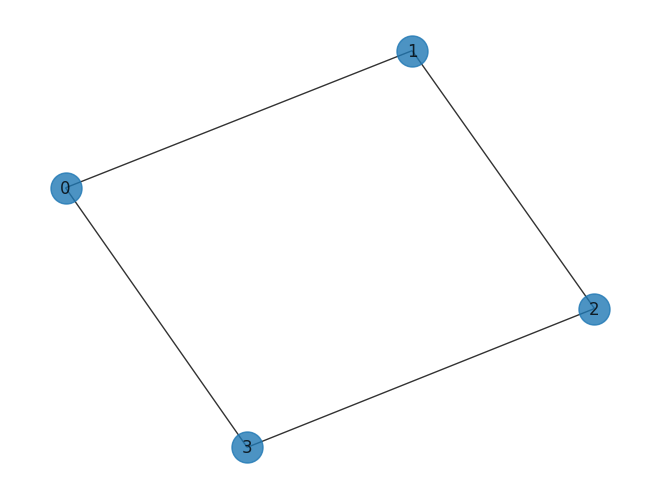

In [43]:
import networkx as nx

G = nx.Graph()
G.add_nodes_from([0, 1, 2, 3])
G.add_edges_from([(0, 1), (1, 2), (2, 3), (3,0)])
nx.draw(G, with_labels=True, alpha=0.8, node_size=500)

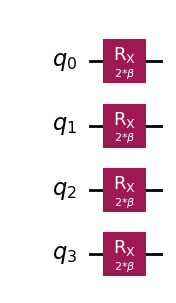

In [44]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.circuit import Parameter

# Adjacency is essentially a matrix which tells you which nodes are
# connected. This matrix is given as a sparse matrix, so we need to
# convert it to a dense matrix
adjacency = nx.adjacency_matrix(G).todense()

nqubits = 4

beta = Parameter("$\\beta$")
qc_mix = QuantumCircuit(nqubits)
for i in range(0, nqubits):
    qc_mix.rx(2 * beta, i)
    
qc_mix.draw('mpl')

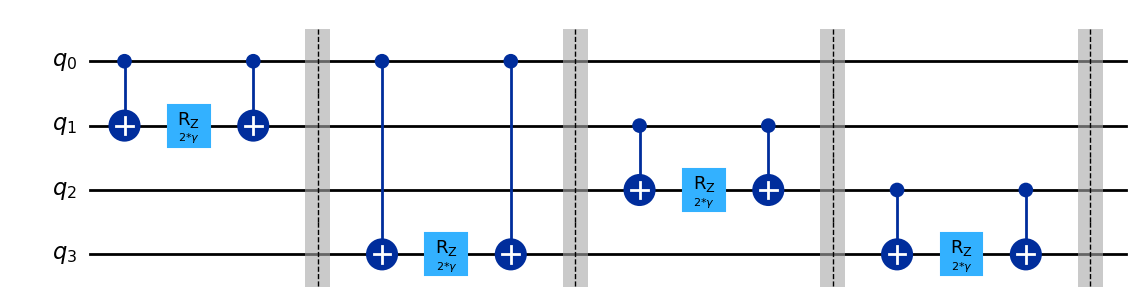

In [45]:
gamma = Parameter("$\\gamma$")
qc_p = QuantumCircuit(nqubits)
for pair in list(G.edges()):  # pairs of nodes
    qc_p.rzz(2 * gamma, pair[0], pair[1])
    qc_p.barrier()
    
qc_p.decompose().draw('mpl')


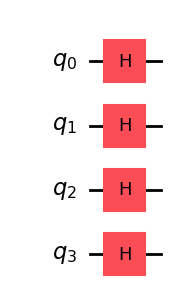

In [46]:
qc_0 = QuantumCircuit(nqubits)
for i in range(0, nqubits):
    qc_0.h(i)
    
qc_0.draw('mpl')

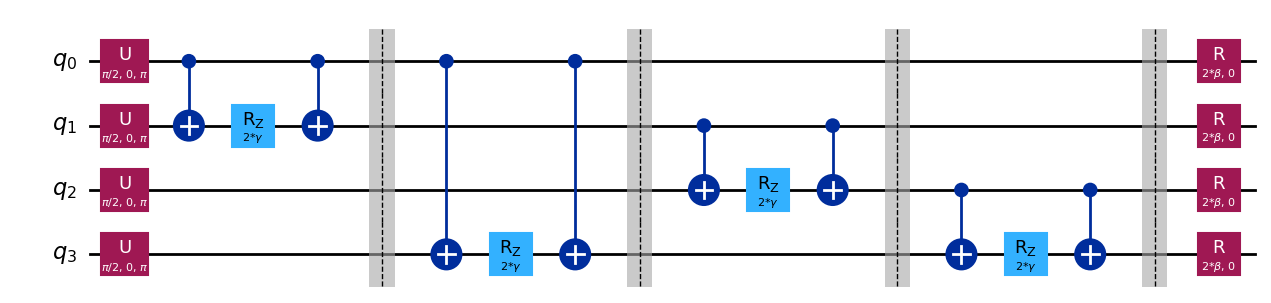

In [47]:
qc_qaoa = QuantumCircuit(nqubits)

qc_qaoa.append(qc_0, [i for i in range(0, nqubits)])
qc_qaoa.append(qc_p, [i for i in range(0, nqubits)])
qc_qaoa.append(qc_mix, [i for i in range(0, nqubits)])

qc_qaoa.decompose().decompose().draw('mpl')

In [48]:
def maxcut_obj(x, G):
    """
    Given a bitstring as a solution, this function returns
    the number of edges shared between the two partitions
    of the graph.
    
    Args:
        x: str
           solution bitstring
           
        G: networkx graph
        
    Returns:
        obj: float
             Objective
    """
    obj = 0
    for i, j in G.edges():
        if x[i] != x[j]:
            obj -= 1
            
    return obj


def compute_expectation(counts, G):
    
    """
    Computes expectation value based on measurement results
    
    Args:
        counts: dict
                key as bitstring, val as count
           
        G: networkx graph
        
    Returns:
        avg: float
             expectation value
    """
    
    avg = 0
    sum_count = 0
    for bitstring, count in counts.items():
        
        obj = maxcut_obj(bitstring[::-1], G)
        avg += obj * count
        sum_count += count
        
    return avg/sum_count


# We will also bring the different circuit components that
# build the qaoa circuit under a single function
def create_qaoa_circ(G, theta):
    
    """
    Creates a parametrized qaoa circuit
    
    Args:  
        G: networkx graph
        theta: list
               unitary parameters
                     
    Returns:
        qc: qiskit circuit
    """
    
    nqubits = len(G.nodes())
    p = len(theta)//2  # number of alternating unitaries
    #print('theta: ', theta)
    #print('p: ', p)
    qc = QuantumCircuit(nqubits)
    
    beta = theta[:p]
    gamma = theta[p:]
    #extra start
    print('beta: ', beta)
    print('gamma: ', gamma)
    ##extra done
    
    # initial_state
    for i in range(0, nqubits):
        qc.h(i)
    
    for irep in range(0, p):
        
        # problem unitary
        for pair in list(G.edges()):
            qc.rzz(2 * gamma[irep], pair[0], pair[1])

        # mixer unitary
        for i in range(0, nqubits):
            qc.rx(2 * beta[irep], i)
            
    qc.measure_all()
        
    return qc

def execute_circ(theta):
        
        qc = create_qaoa_circ(G, theta)
        counts = backend.run(qc, seed_simulator=10, 
                             nshots=512).result().get_counts()
        
        return compute_expectation(counts, G)

# Finally we write a function that executes the circuit on the chosen backend
def get_expectation(G, shots=512):
    
    """
    Runs parametrized circuit
    
    Args:
        G: networkx graph
        p: int,
           Number of repetitions of unitaries
    """
    
#    backend = Aer.get_backend('aer_simulator')
    backend.shots = shots
    
   
    
    return execute_circ

In [49]:
from scipy.optimize import minimize


expectation = get_expectation(G)

res = minimize(expectation, 
                      [1.0, 1.0], 
                      method='COBYLA')                  
res

# Graph beta and gamma parameters in evolution of optimization



beta:  [1.]
gamma:  [1.]
beta:  [2.]
gamma:  [1.]
beta:  [2.]
gamma:  [2.]
beta:  [2.60303802]
gamma:  [0.20228755]
beta:  [2.37777989]
gamma:  [1.32753986]
beta:  [1.91811504]
gamma:  [1.09444497]
beta:  [1.6687284]
gamma:  [1.07694344]
beta:  [1.95589302]
gamma:  [1.12719896]
beta:  [1.94706819]
gamma:  [1.22680881]
beta:  [2.00569795]
gamma:  [1.13161138]
beta:  [1.94992819]
gamma:  [1.15147695]
beta:  [1.9390115]
gamma:  [1.17396752]
beta:  [1.94543007]
gamma:  [1.14929361]
beta:  [1.95839911]
gamma:  [1.14616249]
beta:  [1.96723534]
gamma:  [1.15084449]
beta:  [1.95821652]
gamma:  [1.14116583]
beta:  [1.95964828]
gamma:  [1.14611684]
beta:  [1.95849041]
gamma:  [1.14866082]
beta:  [1.95841737]
gamma:  [1.14666216]
beta:  [1.95845389]
gamma:  [1.14766149]
beta:  [1.95802183]
gamma:  [1.14635631]
beta:  [1.95849383]
gamma:  [1.14656327]
beta:  [1.95837782]
gamma:  [1.14663157]


 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -2.9921875
       x: [ 1.958e+00  1.147e+00]
    nfev: 23
   maxcv: 0.0

beta:  [1.95841737]
gamma:  [1.14666216]
Max cut size found from measurements: 4
Best measured bitstring(s): ['1010', '0101']
Corresponding partitions (set1, set2):
([1, 3], [0, 2])
([0, 2], [1, 3])


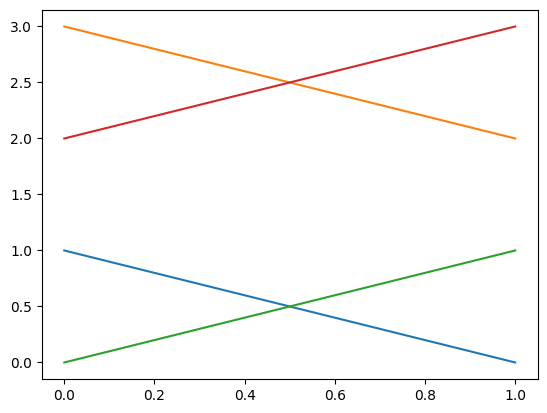

In [52]:
from qiskit.visualization import plot_histogram
from matplotlib import pyplot as plt

backend = Aer.get_backend('aer_simulator')
backend.shots = 512

qc_res = create_qaoa_circ(G, res.x)

counts = backend.run(qc_res, seed_simulator=10).result().get_counts()

plot_histogram(counts)

# Compute the max-cut from the measured counts
# maxcut_obj returns a negative integer ("-#crossing_edges"),
# so we negate it to get the cut size.
best_cut = -999
best_bitstrings = []
for bitstring, cnt in counts.items():
    cut_size = -maxcut_obj(bitstring[::-1], G)
    if cut_size > best_cut:
        best_cut = cut_size
        best_bitstrings = [bitstring]
    elif cut_size == best_cut:
        best_bitstrings.append(bitstring)

print('Max cut size found from measurements:', best_cut)
print('Best measured bitstring(s):', best_bitstrings)

# Also convert best bitstrings to node partitions for clarity
partitions = []
for bs in best_bitstrings:
    bs_rev = bs[::-1]
    left = [i for i, b in enumerate(bs_rev) if b == '1']
    right = [i for i, b in enumerate(bs_rev) if b == '0']
    partitions.append((left, right))

print('Corresponding partitions (set1, set2):')
for p in partitions:
    print(p)
    plt.plot(p)

beta:  [1.]
gamma:  [1.]
beta:  [2.]
gamma:  [1.]
beta:  [2.]
gamma:  [2.]
beta:  [2.60303802]
gamma:  [0.20228755]
beta:  [2.37777989]
gamma:  [1.32753986]
beta:  [1.91811504]
gamma:  [1.09444497]
beta:  [1.6687284]
gamma:  [1.07694344]
beta:  [1.95589302]
gamma:  [1.12719896]
beta:  [1.94706819]
gamma:  [1.22680881]
beta:  [2.00569795]
gamma:  [1.13161138]
beta:  [1.94992819]
gamma:  [1.15147695]
beta:  [1.9390115]
gamma:  [1.17396752]
beta:  [1.94543007]
gamma:  [1.14929361]
beta:  [1.95839911]
gamma:  [1.14616249]
beta:  [1.96723534]
gamma:  [1.15084449]
beta:  [1.95821652]
gamma:  [1.14116583]
beta:  [1.95964828]
gamma:  [1.14611684]
beta:  [1.95849041]
gamma:  [1.14866082]
beta:  [1.95841737]
gamma:  [1.14666216]
beta:  [1.95845389]
gamma:  [1.14766149]
beta:  [1.95802183]
gamma:  [1.14635631]
beta:  [1.95849383]
gamma:  [1.14656327]
beta:  [1.95837782]
gamma:  [1.14663157]


beta:  [1.]
gamma:  [1.]
beta:  [2.]
gamma:  [1.]
beta:  [2.]
gamma:  [2.]
beta:  [2.60303802]
gamma:  [0.20228755]
beta:  [2.37777989]
gamma:  [1.32753986]
beta:  [1.91811504]
gamma:  [1.09444497]
beta:  [1.6687284]
gamma:  [1.07694344]
beta:  [1.95589302]
gamma:  [1.12719896]
beta:  [1.94706819]
gamma:  [1.22680881]
beta:  [2.00569795]
gamma:  [1.13161138]
beta:  [1.94992819]
gamma:  [1.15147695]
beta:  [1.9390115]
gamma:  [1.17396752]
beta:  [1.94543007]
gamma:  [1.14929361]
beta:  [1.95839911]
gamma:  [1.14616249]
beta:  [1.96723534]
gamma:  [1.15084449]
beta:  [1.95821652]
gamma:  [1.14116583]
beta:  [1.95964828]
gamma:  [1.14611684]
beta:  [1.95849041]
gamma:  [1.14866082]
beta:  [1.95841737]
gamma:  [1.14666216]
beta:  [1.95845389]
gamma:  [1.14766149]
beta:  [1.95802183]
gamma:  [1.14635631]
beta:  [1.95849383]
gamma:  [1.14656327]
beta:  [1.95837782]
gamma:  [1.14663157]


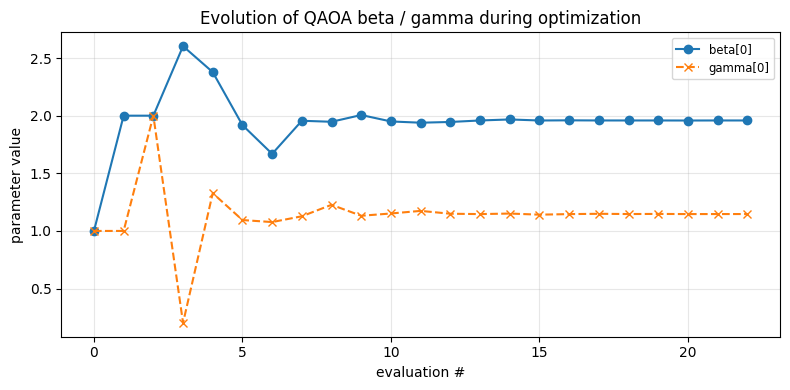

Optimization result:  message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -2.9921875
       x: [ 1.958e+00  1.147e+00]
    nfev: 23
   maxcv: 0.0


In [51]:
history = []

def expectation_with_history(theta):
    # record a copy of the parameters at each evaluation
    history.append(np.array(theta, dtype=float).copy())
    return expectation(theta)

# initial guess (kept as before)
initial_theta = [1.0, 1.0]

# run optimizer using the wrapper so history is populated
res = minimize(expectation_with_history,
               initial_theta,
               method='COBYLA',
               options={'maxiter': 200})

# after optimization: plot evolution of betas and gammas
hist = np.array(history)
if hist.size == 0:
    print("No optimization history recorded.")
else:
    # determine p (number of layers) from parameter length
    total_params = hist.shape[1]
    p = total_params // 2

    it = np.arange(len(hist))
    plt.figure(figsize=(8,4))
    # plot betas
    for irep in range(p):
        plt.plot(it, hist[:, irep], marker='o', label=f'beta[{irep}]')
    # plot gammas
    for irep in range(p):
        plt.plot(it, hist[:, p + irep], marker='x', linestyle='--', label=f'gamma[{irep}]')

    plt.xlabel('evaluation #')
    plt.ylabel('parameter value')
    plt.title('Evolution of QAOA beta / gamma during optimization')
    plt.legend(loc='best', fontsize='small')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print("Optimization result:", res)